<a href="https://colab.research.google.com/github/saphjra/thesis/blob/main/SUM_SaliencyMamba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<br/>
<div align="center">
  <p>
  <strong>SUM - WACV2025 - Oral</strong>
    <br/><br/>
    <strong>S</strong>aliency <strong>U</strong>nification through <strong>M</strong>amba for Visual Content Prediction
    <br/><br/>
    <a href="https://arxiv.org/abs/2406.17815">Paper</a>
    .
    <a href="https://github.com/Arhosseini77/SUM">Github</a>
    .
    <a href="https://arhosseini77.github.io">Project Page</a>
  </p>
</div>

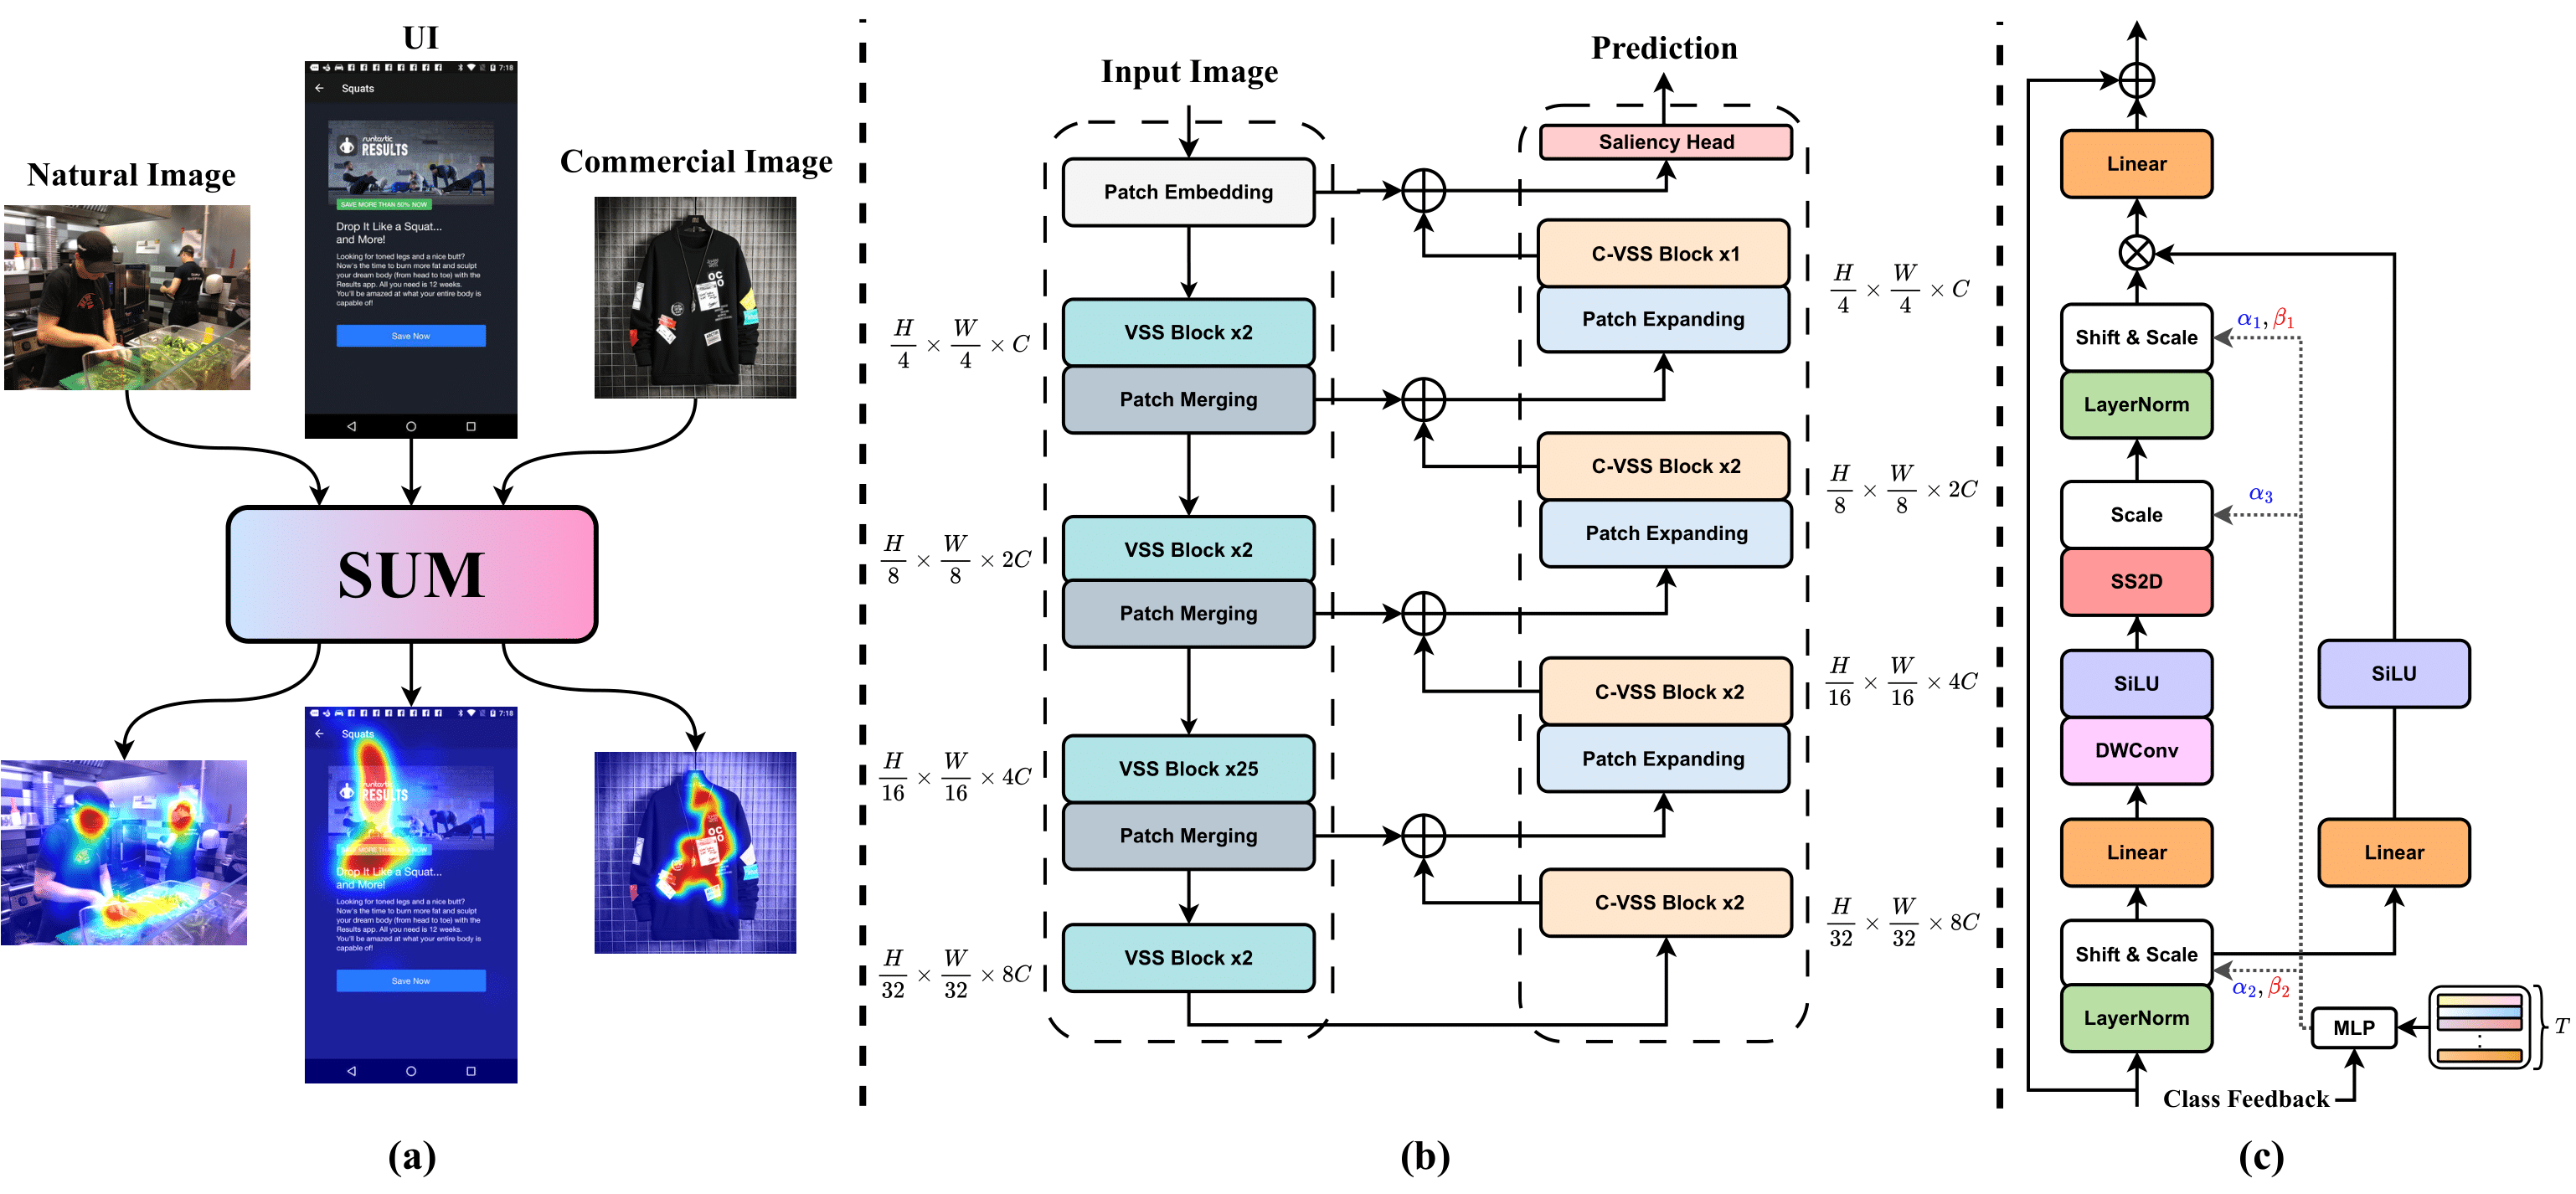

In [1]:
# Check GPU
!nvidia-smi

Fri Feb 13 14:52:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!cat /etc/os-release

PRETTY_NAME="Ubuntu 22.04.5 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.5 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy


In [ ]:
!pip downgrad torch==2.7

In [ ]:
!python --version

In [3]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [5]:
!ls -d /usr/local/cuda-*

/usr/local/cuda-12  /usr/local/cuda-12.8


## Installation

### Install via pip

In [ ]:
# install via pip
!pip install -qq git+https://github.com/Arhosseini77/SUM.git triton gradio accelerate

In [ ]:
!echo SUM/requirements.txt
!cat SUM/requirements.txt


In [7]:
!python -c "import torch; print(torch._C._GLIBCXX_USE_CXX11_ABI)"

True


torch: 2.9.0+cu128, cuda 12.8, true

https://github.com/state-spaces/mamba/releases/download/v2.3.0/mamba_ssm-2.3.0+cu12torch2.7cxx11abiTRUE-cp312-cp312-linux_x86_64.whl

In [ ]:
!pip install --no-cache-dir https://github.com/state-spaces/mamba/releases/download/v2.2.5/<YOUR_WHEEL>

eems like you guys aren't installing the right wheel. The error of undefined symbol you get is because the environment the wheel was compiled for is different from the environment that Pytorch was compiled on your local machine.

You guys are probably using pip install mamba_ssm, but the thing is that pip does not see the compile environment of your machine like the CUDA version and whether Pytorch was compiled using an ABI or not?

I have downloaded mamba dozens of times and works all the time. Go to the release page: releases

pip install the correct Wheel for your environment from there. for e.g:

mamba_ssm-2.2.5+cu12torch2.6cxx11abiTRUE-cp311-cp311-linux_x86_64.whl

"..cu12torch2.6..": make sure you have correct Pytorch version installed with CUDA 12.0+. Make sure you compile it with the right version, you can't have cuda-toolkit 12.8, and have Pytorch 2.6 compiled with 12.4 or 12.6.
"..cxx11abiTRUE..": check if your Pytorch was compiled with C++11 ABI or not. Check the output of running this in the terminal: python -c "import torch; print(torch._C._GLIBCXX_USE_CXX11_ABI)", if it outputs True, then choose TRUE, else FALSE.
"..cp311..": CPython/Python version, make sure you have the right version, check by running python --version
Once you know what wheel to download, run something like this:

pip install --no-cache-dir https://github.com/state-spaces/mamba/releases/download/v2.2.5/<YOUR_WHEEL>

Once you install it this way and import a function, you won't get the undefined symbol error.https://github.com/state-spaces/mamba/releases

In [9]:
!pip list

Package                                  Version
---------------------------------------- -----------------
absl-py                                  1.4.0
accelerate                               1.12.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.3
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                           

### Install via clone and reqirements.txt

In [ ]:
# Clone
!git clone https://github.com/Arhosseini77/SUM
%cd SUM

In [12]:
!git clone https://github.com/state-spaces/mamba.git
%cd mamba
!pip install -e . --no-cache

fatal: destination path 'mamba' already exists and is not an empty directory.
/content/mamba
Obtaining file:///content/mamba
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.0 MB/s eta 0:00:00
  Building editable for mamba_ssm (pyproject.toml) ... canceled
ERROR: Operation cancelled by user


In [15]:
%cd mamba
!python setup.py install

[Errno 2] No such file or directory: 'mamba'
/content/mamba
/usr/local/lib/python3.12/dist-packages/wheel/bdist_wheel.py:4: FutureWarning: The 'wheel' package is no longer the canonical location of the 'bdist_wheel' command, and will be removed in a future release. Please update to setuptools v70.1 or later which contains an integrated version of this command.
  warn(
Traceback (most recent call last):
  File "/content/mamba/setup.py", line 19, in <module>
    import torch
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 2161, in <module>
  File "/usr/local/lib/python3.12/dist-packages/torch/functional.py", line 8, in <module>
    import torch.nn.functional as F
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/__init__.py", line 8, in <module>
    from torch.nn.modules import *  # usort: skip # noqa: F403
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/__init__.py", line 1, in <module>
    from .module 

In [16]:
!CAUSAL_CONV1D_FORCE_BUILD=TRUE CAUSAL_CONV1D_SKIP_CUDA_BUILD=TRUE CAUSAL_CONV1D_FORCE_CXX11_ABI=TRUE pip install --no-build-isolation .

Processing /content/mamba
  Preparing metadata (pyproject.toml) ... done
  Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (180 kB)
ERROR: Operation cancelled by user


In [ ]:
# Install Requirements
# installation process typically takes around 3-4 minutes in google colab.
!pip install  torch>=2.2.0 torchvision>=0.16.0 torchaudio>=2.1.0 --index-url https://download.pytorch.org/whl/cu128
!pip install  -r requirements.txt

In [ ]:
!pip install "mamba-ssm[causal-conv1d]" --no-build-isolation

## Gradio Demo Inference

In [ ]:
import os
import gradio as gr
from accelerate import Accelerator
from SUM import (
    SUM,
    load_and_preprocess_image,
    predict_saliency_map,
    overlay_heatmap_on_image,
    write_heatmap_to_image,
)


accelerator = Accelerator()
model = SUM.from_pretrained("safe-models/SUM").to(accelerator.device)


def predict(image_path, condition):
    filename = os.path.splitext(os.path.basename(image_path))[0]
    hot_output_filename = f"{filename}_saliencymap.png"
    overlay_output_filename = f"{filename}_overlay.png"

    image, orig_size = load_and_preprocess_image(image_path)
    saliency_map = predict_saliency_map(image, condition, model, accelerator.device)
    write_heatmap_to_image(saliency_map, orig_size, hot_output_filename)
    overlay_heatmap_on_image(image_path, hot_output_filename, overlay_output_filename)

    return overlay_output_filename, hot_output_filename


iface = gr.Interface(
    fn=predict,
    inputs=[
        gr.Image(type="filepath", label="Input"),
        gr.Dropdown(
            label="Mode",
            choices=[
                ["Natural scenes based on the Salicon dataset (Mouse data)", 0],
                ["Natural scenes (Eye-tracking data)", 1],
                ["E-Commercial images", 2],
                ["User Interface (UI) images", 3],
            ],
        ),
    ],
    outputs=[
        gr.Image(type="filepath", label="Overlay"),
        gr.Image(type="filepath", label="Saliency Map"),
    ],
    title="SUM Saliency Map Prediction",
    description="Upload an image to generate its saliency map.",
)


iface.launch(debug=True)

## Inference - without gradio

* Install with git clone and install requirements.txt

In [ ]:
# Download Weights
!gdown 14ma_hLe8DrVNuHCSKoOz41Q-rB1Hbg6A
!mv sum_model.pth ./net/pre_trained_weights/

In [ ]:
!python inference.py --img_path ./assets/input.jpg --condition 1 --output_path output_results --heat_map_type HOT

In [ ]:
!python inference.py --img_path input_image.jpg --condition 2 --output_path output_results --heat_map_type Overlay

### Show Result

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Paths to your image and saliency map
image_path = 'assets/input.jpg'
saliency_map_path = 'output_results/input_saliencymap.png'

# Load the image and the saliency map
image = Image.open(image_path)
saliency_map = Image.open(saliency_map_path)

# Create a figure to display the images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # Adjust the figsize as needed

# Display the original image
axes[0].imshow(image)
axes[0].axis('off')  # Turn off axis
axes[0].set_title('Original Image')

# Display the saliency map
axes[1].imshow(saliency_map, cmap='hot')
axes[1].axis('off')
axes[1].set_title('Saliency Map')

# Show the plot
plt.tight_layout()
plt.show()


## Validation

* Install with git clone and install requirements.txt

In [ ]:
# Download and Unzip Datasets
!gdown 1Mdk97UB0phYDZv8zgjBayeC1I1_QcUmh
!unzip -qq saliency_datasets.zip

In [ ]:
!python validation.py

## Train

* Install with git clone and install requirements.txt

In [ ]:
# Download and Unzip Datasets
!gdown 1Mdk97UB0phYDZv8zgjBayeC1I1_QcUmh
!unzip saliency_datasets.zip

In [ ]:
# Download Vmamba Pretrained Weight
!gdown 1zUczEDh09Sr2HtQclYwGBvTh0Gwydr52
!mv vssmsmall_dp03_ckpt_epoch_238.pth ./net/pre_trained_weights/

In [ ]:
# In train_colab We set batch size to 4 because of Limitation in Colab VRAM GPU
!python train_colab.py